# BITCOIN PRICE PREDICTOR

In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error as rmse


In [2]:
%pip install yfinance

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0 -> 26.1.2
[notice] To update, run: C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [3]:
import yfinance as yf

In [4]:
data = yf.download("BTC-USD", "2024-01-01", "2026-06-25", auto_adjust=True)
data.tail()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2026-06-20,64239.675781,64307.136719,63149.660156,63535.808594,17486384117
2026-06-21,63237.539062,64506.578125,63221.000000,64242.324219,15739619591
2026-06-22,63952.105469,65544.000000,63233.531250,63240.789062,26561496819
2026-06-23,62668.019531,64196.562500,61893.207031,63952.792969,29608942370
2026-06-24,60995.132812,63097.757812,59029.855469,62663.031250,42644106535


In [5]:
data.shape

(906, 5)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 906 entries, 2024-01-01 to 2026-06-24
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, BTC-USD)   906 non-null    float64
 1   (High, BTC-USD)    906 non-null    float64
 2   (Low, BTC-USD)     906 non-null    float64
 3   (Open, BTC-USD)    906 non-null    float64
 4   (Volume, BTC-USD)  906 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 42.5 KB


In [7]:
data.describe()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
count,906.000000,906.000000,906.000000,906.000000,9.060000e+02
mean,81996.692277,83390.996400,80475.440152,81975.808594,4.397978e+10
std,20705.310147,20876.974744,20541.274132,20735.635736,2.304622e+10
min,39507.367188,40127.351562,38521.894531,39518.714844,9.344044e+09
25%,65609.306641,66943.375000,63932.939453,65608.986328,2.763705e+10
50%,79451.628906,81554.632812,78052.519531,79450.996094,3.968728e+10
75%,98329.193359,100461.072266,96413.878906,98334.242188,5.482933e+10
max,124752.531250,126198.070312,123196.046875,124752.140625,1.817464e+11


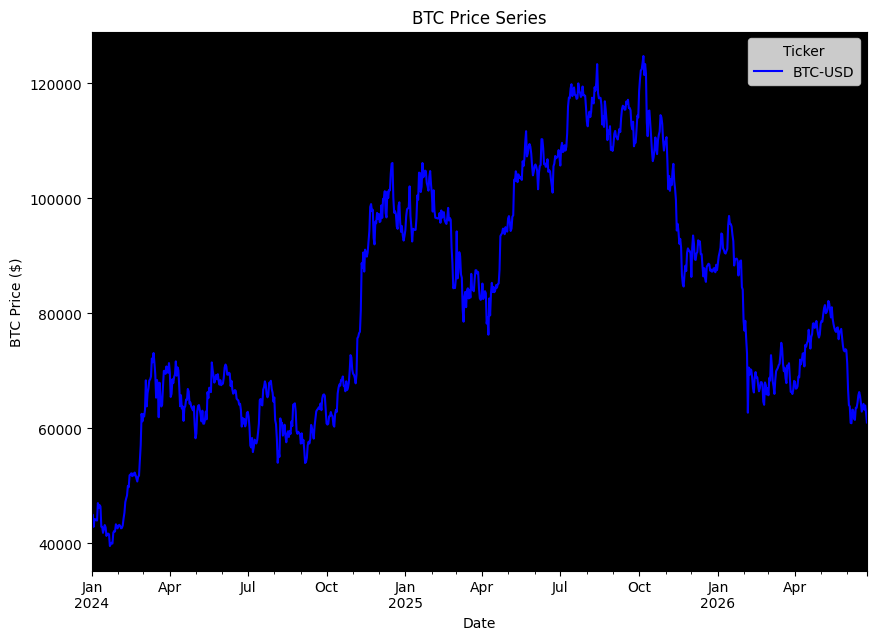

In [8]:
data.Close.plot(figsize=(10,7), color='b').set_facecolor('black')
plt.ylabel('BTC Price ($)')
plt.title('BTC Price Series')
plt.show()

<Axes: ylabel='Count'>

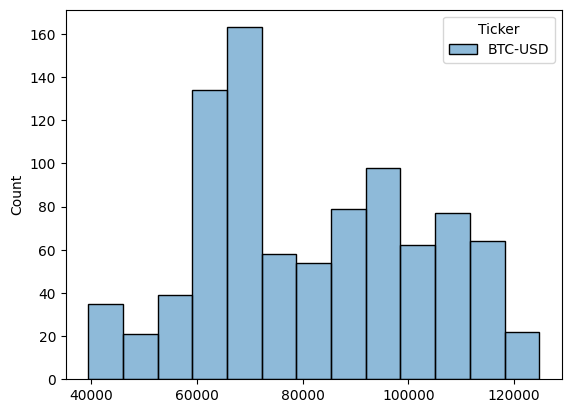

In [9]:
sns.histplot(data["Close"])

<Axes: ylabel='Count'>

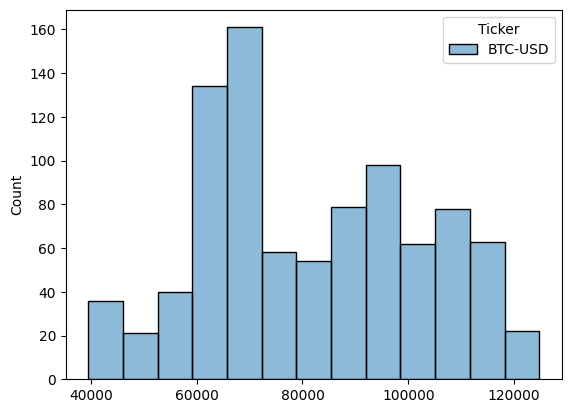

In [10]:
sns.histplot(data["Open"])

<Axes: ylabel='Count'>

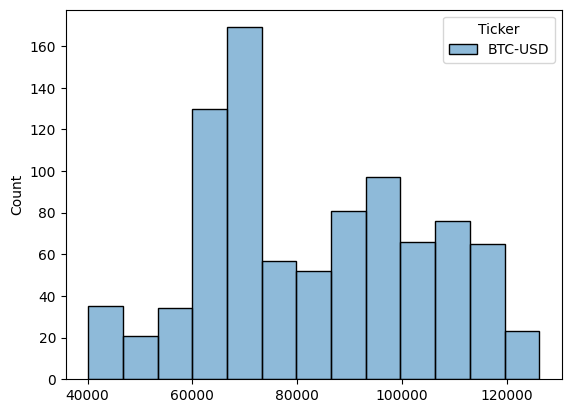

In [11]:
sns.histplot(data["High"])

In [12]:
X = data.drop('Close', axis=1)
y = data['Close']

In [13]:
X_train, y_train = X.iloc[0:int(0.8*960)], y.iloc[0:int(0.8*960)]
X_test, y_test = X.iloc[int(0.8*960):], y.iloc[int(0.8*960):]

In [14]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((768, 4), (138, 4), (768, 1), (138, 1))

# UTILS

In [189]:
model_names = []
model_rmse = []
model_r2_score = []

In [190]:
from datetime import datetime
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.metrics import r2_score
import joblib

def eval_save_model(model):
    model.fit(X_train, y_train)    
    name = model.__class__.__name__
    rmse_model = rmse(model.predict(X_test), y_test)
    r2_score_model = r2_score(model.predict(X_test), y_test)
    
    model_names.append(name)
    model_rmse.append(rmse_model)
    model_r2_score.append(r2_score_model)
    print(f'{name}:\n\tRMSE:{rmse_model}\n\tR2-score:{r2_score_model}')

def save_perfs(perfs, fname=None):
    if fname is None:
        fname = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    perfs.to_csv(f'models/perfs/{fname}.csv')

def visualization_regression_perfs(df,title=None):
    plt.title(title)
    sns.barplot(df.sort_values(by='RMSE'),
               x='RMSE',
               y='name');

def save_model(model, fname):
    joblib.dump(model, f'models/saved{fname}.pkl',compress=3)

def reset():
    model_names.clear()
    model_rmse.clear()
    model_r2_score.clear()

# BASELINE MODELS (V1) WITHOUT PREPROCESSING

## Linear models

In [191]:
from sklearn.linear_model import LinearRegression

eval_save_model(LinearRegression())

LinearRegression:
	RMSE:1892.2802847076869
	R2-score:0.8396100723458306


In [192]:
from sklearn.linear_model import Lasso

eval_save_model(Lasso())

Lasso:
	RMSE:576.4014880098556
	R2-score:0.9890002866672458


C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.633e+08, tolerance: 3.643e+07
  model = cd_fast.enet_coordinate_descent(


In [193]:
from sklearn.linear_model import Ridge

eval_save_model(Ridge())

Ridge:
	RMSE:567.5322803646945
	R2-score:0.9895077584232106


C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.35334e-46): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


## SUPPORT VECTOR MACHINE

In [194]:
from sklearn.svm import SVR


eval_save_model(SVR())

SVR:
	RMSE:17083.645231434362
	R2-score:-179701.13541452357


C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


## KNN

In [195]:
from sklearn.neighbors import KNeighborsRegressor

eval_save_model(KNeighborsRegressor())

KNeighborsRegressor:
	RMSE:16226.720524757495
	R2-score:-0.6552873200203657


## TREE

In [196]:
from sklearn.tree import DecisionTreeRegressor

eval_save_model(DecisionTreeRegressor())

DecisionTreeRegressor:
	RMSE:1228.205232892983
	R2-score:0.9450582770966295


## ENSEMBLE LEARNING

In [197]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

eval_save_model(RandomForestRegressor())
eval_save_model(GradientBoostingRegressor())

C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor:
	RMSE:809.6655030416308
	R2-score:0.9776547620317682


C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\ensemble\_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


GradientBoostingRegressor:
	RMSE:1013.0971048845844
	R2-score:0.9631992532689622


In [198]:
from xgboost import XGBRegressor

eval_save_model(XGBRegressor())

XGBRegressor:
	RMSE:1172.3359375
	R2-score:0.9450927972793579


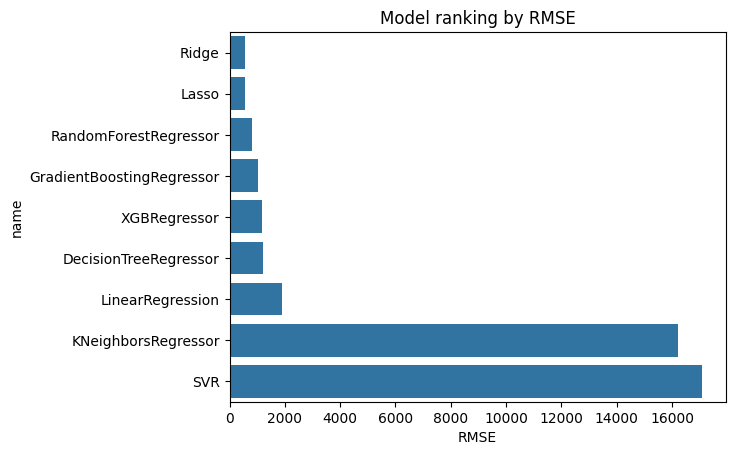

In [199]:
baseline_perfs = pd.DataFrame({
    'name': model_names,
    'RMSE': model_rmse,
    'R2_score': model_r2_score
})

plt.title('Model ranking by RMSE')

sns.barplot(baseline_perfs.sort_values(by='RMSE'),
            x='RMSE',
            y='name');

According to the RMSE ranking, LinearRegression and Ridge are the best models.

In [26]:
save_perfs(baseline_perfs, 'baseline')

# HYPERPARAMETERS TUNING

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

## Preprocessing

In [28]:
cols = list(X_train.columns)

In [29]:
scaler = StandardScaler().fit(X_train)

X_train[cols], X_test[cols] = scaler.transform(X_train), scaler.transform(X_test)

C:\Users\KRYPTONIUM\AppData\Local\Temp\ipykernel_14936\2844421937.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[cols], X_test[cols] = scaler.transform(X_train), scaler.transform(X_test)


## Baseline models with preprocessing

In [181]:
reset()

### Linear models

In [182]:
eval_save_model(LinearRegression())
eval_save_model(Lasso())
eval_save_model(Ridge())

LinearRegression:
	RMSE:1892.2802847076869
	R2-score:0.8396100723458306
Lasso:
	RMSE:576.4014880098556
	R2-score:0.9890002866672458
Ridge:
	RMSE:567.5322803646945
	R2-score:0.9895077584232106


C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.633e+08, tolerance: 3.643e+07
  model = cd_fast.enet_coordinate_descent(
C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.35334e-46): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


### Support Vector Machine

In [183]:
eval_save_model(SVR())

SVR:
	RMSE:17083.645231434362
	R2-score:-179701.13541452357


C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


### KNN

In [184]:
eval_save_model(KNeighborsRegressor())

KNeighborsRegressor:
	RMSE:16226.720524757495
	R2-score:-0.6552873200203657


### Decision Tree

In [185]:
eval_save_model(DecisionTreeRegressor())

DecisionTreeRegressor:
	RMSE:1238.361163794854
	R2-score:0.9424672912772819


### Ensemble Learning

In [186]:
eval_save_model(RandomForestRegressor(random_state=42))
eval_save_model(XGBRegressor(random_state=42))
eval_save_model(GradientBoostingRegressor(random_state=42))

C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor:
	RMSE:787.6815424173438
	R2-score:0.9784772727836664
XGBRegressor:
	RMSE:1172.3359375
	R2-score:0.9450927972793579


C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\ensemble\_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


GradientBoostingRegressor:
	RMSE:1017.1966910091592
	R2-score:0.9629940844097031


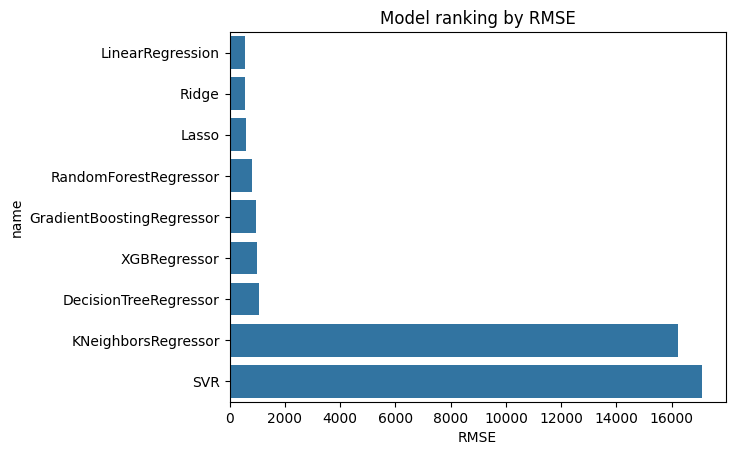

In [187]:
plt.title('Model ranking by RMSE')

sns.barplot(baseline_perfs.sort_values(by='RMSE'),
            x='RMSE',
            y='name');
plt.savefig('figures/Baseline_models_ranking.png')

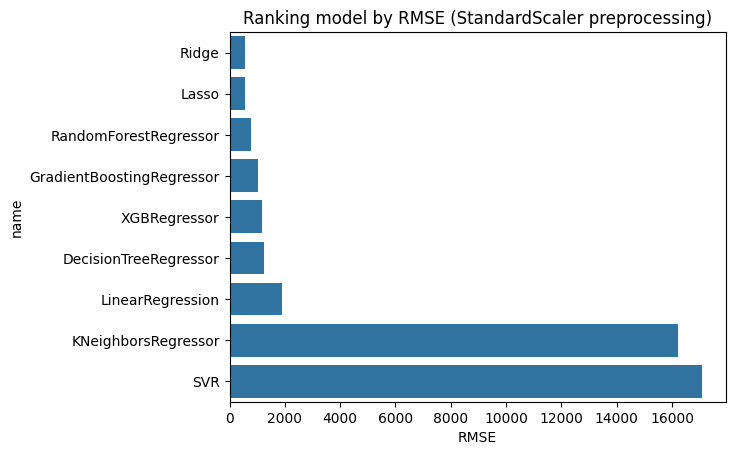

In [188]:
scaler_perfs = pd.DataFrame({
    'name': model_names,
    'RMSE': model_rmse,
    'R2_score': model_r2_score
})

plt.title('Ranking model by RMSE (StandardScaler preprocessing)')
sns.barplot(scaler_perfs.sort_values(by='RMSE'),
           x='RMSE',
           y='name');
plt.savefig('figures/RMSE(StandardScaler preprocessing)')

In [57]:
scaler_perfs

,name,RMSE,R2_score
0,LinearRegression,1892.280285,0.839610
1,Lasso,576.401488,0.989000
2,Ridge,567.532280,0.989508
3,SVR,17083.645231,-179701.135415
4,KNeighborsRegressor,16226.720525,-0.655287
5,DecisionTreeRegressor,1228.402018,0.942760
6,RandomForestRegressor,787.681542,0.978477
7,XGBRegressor,1172.335938,0.945093
8,GradientBoostingRegressor,1017.196691,0.962994


In [58]:
baseline_perfs

,name,RMSE,R2_score
0,LinearRegression,575.876201,0.989140
1,Lasso,582.396239,0.988915
2,Ridge,575.876201,0.989140
3,SVR,17092.672981,-130362.529254
4,KNeighborsRegressor,16226.720525,-0.655287
5,DecisionTreeRegressor,1051.060666,0.960380
6,RandomForestRegressor,822.944763,0.977458
7,GradientBoostingRegressor,942.300592,0.968622
8,XGBRegressor,976.564941,0.966595


With StandardScaler preprocessing, model performance get worse

## Preprocessing with PolynomialFeatures

In [171]:
reset()

In [172]:
X_train, y_train = X.iloc[0:int(0.8*960)], y.iloc[0:int(0.8*960)]
X_test, y_test = X.iloc[int(0.8*960):], y.iloc[int(0.8*960):]

In [173]:
from sklearn.preprocessing import PolynomialFeatures

In [174]:
poly = PolynomialFeatures()

X_train = poly.fit_transform(X_train)
X_test = poly.fit_transform(X_test)

## Baseline models with PolynomialFeatures preprocessing

In [175]:
eval_save_model(LinearRegression())
eval_save_model(Lasso())
eval_save_model(Ridge())

LinearRegression:
	RMSE:1892.2802847076869
	R2-score:0.8396100723458306
Lasso:
	RMSE:576.4014880098556
	R2-score:0.9890002866672458
Ridge:
	RMSE:567.5322803646945
	R2-score:0.9895077584232106


C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.633e+08, tolerance: 3.643e+07
  model = cd_fast.enet_coordinate_descent(
C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.35334e-46): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


In [176]:
eval_save_model(SVR())

C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR:
	RMSE:17083.645231434362
	R2-score:-179701.13541452357


In [177]:
eval_save_model(DecisionTreeRegressor())

DecisionTreeRegressor:
	RMSE:1201.357485391734
	R2-score:0.9500949324087885


In [178]:
eval_save_model(RandomForestRegressor(random_state=42))
eval_save_model(XGBRegressor(random_state=42))
eval_save_model(GradientBoostingRegressor(random_state=42))

C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor:
	RMSE:787.6815424173438
	R2-score:0.9784772727836664
XGBRegressor:
	RMSE:1172.3359375
	R2-score:0.9450927972793579


C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\ensemble\_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


GradientBoostingRegressor:
	RMSE:1017.1966910091592
	R2-score:0.9629940844097031


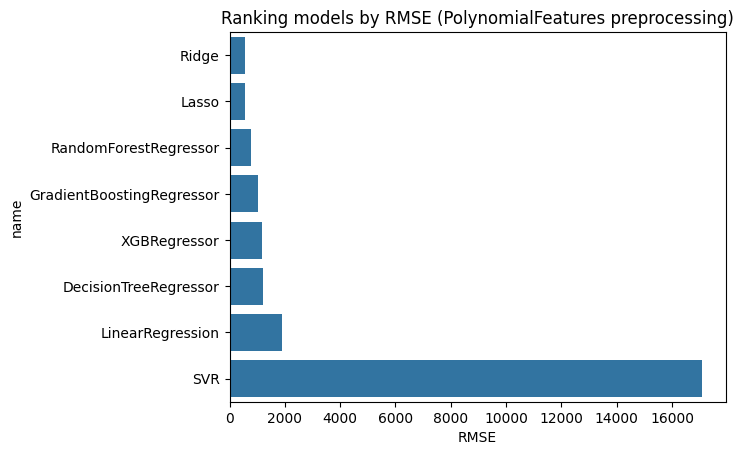

In [179]:
poly_perfs = pd.DataFrame({
    'name': model_names,
    'RMSE': model_rmse,
    'R2_score': model_r2_score
})

visualization_regression_perfs(poly_perfs, 'Ranking models by RMSE (PolynomialFeatures preprocessing)')
plt.savefig('figures/RMSE(PolynomialFeatures preprocessing)')

In [69]:
save_perfs(poly_perfs, 'Polynomial_preprocessing_perfs')

In [70]:
save_perfs(scaler_perfs, 'StandardScaler_preprocessing_perfs')

Some models like Ridge, Lasso and RandomForest get better.

## Optimizing Models

We'll optimize all models except SVR and KNN because they present the worst results.

In [71]:
X_train, y_train = X.iloc[0:int(0.8*960)], y.iloc[0:int(0.8*960)]
X_test, y_test = X.iloc[int(0.8*960):], y.iloc[int(0.8*960):]

In [74]:
pipe = Pipeline(
    steps=[
        ("poly", PolynomialFeatures(include_bias=False)), 
        ("scaler", StandardScaler()),  
        ("regressor", "passthrough"),
    ]
)

# 3. GridSearch models and hyperparameters
param_grid = [
    {
        "poly__degree":[2,3],  
        "regressor": [LinearRegression()],
    },
    
    {
        "poly__degree":[2,3],
        "regressor": [Lasso(random_state=42, max_iter=2000)],
        "regressor__alpha": [0.01, 0.1, 1.0],
    },

    {
        "poly__degree":[2,3],
        "regressor": [Ridge(random_state=42)],
        "regressor__alpha": [0.1, 1.0, 10.0],
    },
    {
        "poly__degree":[2,3],
        "regressor": [DecisionTreeRegressor(random_state=42)],
        "regressor__max_depth":[1,3,5,10],
    },
    {
        "poly__degree":[2,3],
        "regressor": [RandomForestRegressor(random_state=42)],
        "regressor__n_estimators":[1,10,50,100,250,500,1000],
        "regressor__max_depth":[1,2,5,10],
    },
    {
        "poly__degree":[2,3],
        "regressor": [GradientBoostingRegressor(random_state=42)],
        "regressor__n_estimators":[1,10,50,100,250,500,1000],
        "regressor__learning_rate": [0.001, 0.01, 0.1, 0.25, 0.5, 0.8, 1],
    },
    {
        "poly__degree":[2,3],
        "regressor": [XGBRegressor(random_state=42)],
        "regressor__n_estimators":[1,10,50,100,250,500,1000],
        "regressor__learning_rate": [0.001, 0.01, 0.1, 0.25, 0.5, 0.8, 1],
    },
]

# 4. Exécution de la recherche
grid = GridSearchCV(
    estimator=pipe, 
    param_grid=param_grid, 
    cv=5, 
    scoring="neg_root_mean_squared_error", 
    n_jobs=-1, 
    verbose=1
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 274 candidates, totalling 1370 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('poly',
                                        PolynomialFeatures(include_bias=False)),
                                       ('scaler', StandardScaler()),
                                       ('regressor', 'passthrough')]),
             n_jobs=-1,
             param_grid=[{'poly__degree': [2, 3],
                          'regressor': [LinearRegression()]},
                         {'poly__degree': [2, 3],
                          'regressor': [Lasso(max_iter=2000, random_state=42)],
                          'regressor__alpha': [0.01, 0.1, 1.0]},
                         {'poly__degree...
                                                     max_delta_step=None,
                                                     max_depth=None,
                                                     max_leaves=None,
                                                     min_child_weight=None,
                                                     missing=nan,
                                                     monotone_constraints=None,
                                                     multi_strategy=None,
                                                     n_estimators=None,
                                                     n_jobs=None,
                                                     num_parallel_tree=None, ...)],
                          'regressor__learning_rate': [0.001, 0.01, 0.1, 0.25,
                                                       0.5, 0.8, 1],
                          'regressor__n_estimators': [1, 10, 50, 100, 250, 500,
                                                      1000]}],
             scoring='neg_root_mean_squared_error', verbose=1)

In [85]:
pipe_poly_scaler = pd.DataFrame(grid.cv_results_).sort_values(by='rank_test_score')
save_perfs(pipe_poly_scaler, 'pipe_poly_scaler_perfs')

In [94]:
pipe2 = Pipeline(
    steps=[
        ("scaler", StandardScaler()),  
        ("regressor", "passthrough"),
    ]
)

# 3. GridSearch models and hyperparameters
param_grid = [
    {
        "regressor": [LinearRegression()],
    },
    
    {
        "regressor": [Lasso(random_state=42, max_iter=2000)],
        "regressor__alpha": [0.01, 0.1, 1.0],
    },

    {
        "regressor": [Ridge(random_state=42)],
        "regressor__alpha": [0.1, 1.0, 10.0],
    },
    {
        "regressor": [DecisionTreeRegressor(random_state=42)],
        "regressor__max_depth":[1,3,5,10],
    },
    {
        "regressor": [RandomForestRegressor(random_state=42)],
        "regressor__n_estimators":[1,10,50,100,250,500,1000],
        "regressor__max_depth":[1,2,5,10],
    },
    {
        "regressor": [GradientBoostingRegressor(random_state=42)],
        "regressor__n_estimators":[1,10,50,100,250,500,1000],
        "regressor__learning_rate": [0.001, 0.01, 0.1, 0.25, 0.5, 0.8, 1],
    },
    {
        "regressor": [XGBRegressor(random_state=42)],
        "regressor__n_estimators":[1,10,50,100,250,500,1000],
        "regressor__learning_rate": [0.001, 0.01, 0.1, 0.25, 0.5, 0.8, 1],
    },
]

# 4. Exécution de la recherche
grid2 = GridSearchCV(
    estimator=pipe2, 
    param_grid=param_grid, 
    cv=5, 
    scoring="neg_root_mean_squared_error", 
    n_jobs=-1, 
    verbose=1
)

grid2.fit(X_train, y_train)

Fitting 5 folds for each of 137 candidates, totalling 685 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('regressor', 'passthrough')]),
             n_jobs=-1,
             param_grid=[{'regressor': [LinearRegression()]},
                         {'regressor': [Lasso(max_iter=2000, random_state=42)],
                          'regressor__alpha': [0.01, 0.1, 1.0]},
                         {'regressor': [Ridge(random_state=42)],
                          'regressor__alpha': [0.1, 1.0, 10.0]},
                         {'regressor': [DecisionTreeRegre...
                                                     max_delta_step=None,
                                                     max_depth=None,
                                                     max_leaves=None,
                                                     min_child_weight=None,
                                                     missing=nan,
                                                     monotone_constraints=None,
                                                     multi_strategy=None,
                                                     n_estimators=None,
                                                     n_jobs=None,
                                                     num_parallel_tree=None, ...)],
                          'regressor__learning_rate': [0.001, 0.01, 0.1, 0.25,
                                                       0.5, 0.8, 1],
                          'regressor__n_estimators': [1, 10, 50, 100, 250, 500,
                                                      1000]}],
             scoring='neg_root_mean_squared_error', verbose=1)

In [98]:
pipe_scaler = pd.DataFrame(grid2.cv_results_).sort_values(by='rank_test_score')
pipe_scaler

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_regressor,param_regressor__alpha,param_regressor__max_depth,param_regressor__n_estimators,param_regressor__learning_rate,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.025202,0.006067,0.020383,0.006447,LinearRegression(),NaN,NaN,NaN,NaN,{'regressor': LinearRegression()},-585.884458,-609.532587,-1139.206382,-794.662027,-898.577370,-805.572565,203.359285,1
2,0.043219,0.007347,0.015756,0.003561,"Lasso(max_iter=2000, random_state=42)",0.10,NaN,NaN,NaN,"{'regressor': Lasso(max_iter=2000, random_stat...",-586.074105,-609.520242,-1143.585108,-794.665193,-898.597158,-806.488361,204.761773,2
1,0.048966,0.007311,0.020988,0.004157,"Lasso(max_iter=2000, random_state=42)",0.01,NaN,NaN,NaN,"{'regressor': Lasso(max_iter=2000, random_stat...",-585.980584,-609.555825,-1144.204169,-794.668164,-898.592976,-806.600344,204.978528,3
3,0.042512,0.006816,0.014763,0.002810,"Lasso(max_iter=2000, random_state=42)",1.00,NaN,NaN,NaN,"{'regressor': Lasso(max_iter=2000, random_stat...",-587.474844,-608.940513,-1144.133200,-794.335608,-898.589324,-806.694698,204.756526,4
4,0.028916,0.002884,0.012850,0.005065,Ridge(random_state=42),0.10,NaN,NaN,NaN,"{'regressor': Ridge(random_state=42), 'regress...",-596.929933,-607.564313,-1130.531051,-803.408854,-904.744076,-808.635646,199.062699,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,0.052652,0.011883,0.015022,0.004289,"XGBRegressor(base_score=None, booster=None, ca...",NaN,NaN,10.0,0.001,"{'regressor': XGBRegressor(base_score=None, bo...",-33292.289062,-26346.750000,-13751.908203,-29626.900391,-22633.517578,-25130.273047,6693.563378,133
46,0.029326,0.004185,0.014645,0.003964,GradientBoostingRegressor(random_state=42),NaN,NaN,1.0,0.010,{'regressor': GradientBoostingRegressor(random...,-33287.216775,-26382.626448,-13726.188088,-29616.082484,-22640.415764,-25130.505912,6700.435047,134
40,0.088373,0.010645,0.015597,0.004056,GradientBoostingRegressor(random_state=42),NaN,NaN,10.0,0.001,{'regressor': GradientBoostingRegressor(random...,-33289.141415,-26384.900440,-13727.842174,-29618.255172,-22639.409643,-25131.909769,6700.791347,135
88,0.036861,0.006903,0.014220,0.002205,"XGBRegressor(base_score=None, booster=None, ca...",NaN,NaN,1.0,0.001,"{'regressor': XGBRegressor(base_score=None, bo...",-33528.921875,-26586.443359,-13860.034180,-29875.785156,-22835.257812,-25337.288477,6741.642551,136


In [99]:
pipe3 = Pipeline(
    steps=[
        ("regressor", "passthrough"),
    ]
)

# 3. GridSearch models and hyperparameters
param_grid = [
    {
        "regressor": [LinearRegression()],
    },
    
    {
        "regressor": [Lasso(random_state=42, max_iter=2000)],
        "regressor__alpha": [0.01, 0.1, 1.0],
    },

    {
        "regressor": [Ridge(random_state=42)],
        "regressor__alpha": [0.1, 1.0, 10.0],
    },
    {
        "regressor": [DecisionTreeRegressor(random_state=42)],
        "regressor__max_depth":[1,3,5,10],
    },
    {
        "regressor": [RandomForestRegressor(random_state=42)],
        "regressor__n_estimators":[1,10,50,100,250,500,1000],
        "regressor__max_depth":[1,2,5,10],
    },
    {
        "regressor": [GradientBoostingRegressor(random_state=42)],
        "regressor__n_estimators":[1,10,50,100,250,500,1000],
        "regressor__learning_rate": [0.001, 0.01, 0.1, 0.25, 0.5, 0.8, 1],
    },
    {
        "regressor": [XGBRegressor(random_state=42)],
        "regressor__n_estimators":[1,10,50,100,250,500,1000],
        "regressor__learning_rate": [0.001, 0.01, 0.1, 0.25, 0.5, 0.8, 1],
    },
]

# 4. Exécution de la recherche
grid3 = GridSearchCV(
    estimator=pipe3, 
    param_grid=param_grid, 
    cv=5, 
    scoring="neg_root_mean_squared_error", 
    n_jobs=-1, 
    verbose=1
)

grid3.fit(X_train, y_train)

Fitting 5 folds for each of 137 candidates, totalling 685 fits


GridSearchCV(cv=5, estimator=Pipeline(steps=[('regressor', 'passthrough')]),
             n_jobs=-1,
             param_grid=[{'regressor': [LinearRegression()]},
                         {'regressor': [Lasso(max_iter=2000, random_state=42)],
                          'regressor__alpha': [0.01, 0.1, 1.0]},
                         {'regressor': [Ridge(random_state=42)],
                          'regressor__alpha': [0.1, 1.0, 10.0]},
                         {'regressor': [DecisionTreeRegressor(random_state=42)],
                          'regr...
                                                     max_delta_step=None,
                                                     max_depth=None,
                                                     max_leaves=None,
                                                     min_child_weight=None,
                                                     missing=nan,
                                                     monotone_constraints=None,
                                                     multi_strategy=None,
                                                     n_estimators=None,
                                                     n_jobs=None,
                                                     num_parallel_tree=None, ...)],
                          'regressor__learning_rate': [0.001, 0.01, 0.1, 0.25,
                                                       0.5, 0.8, 1],
                          'regressor__n_estimators': [1, 10, 50, 100, 250, 500,
                                                      1000]}],
             scoring='neg_root_mean_squared_error', verbose=1)

In [100]:
simple_pipe = pd.DataFrame(grid3.cv_results_).sort_values(by='rank_test_score')
simple_pipe

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_regressor,param_regressor__alpha,param_regressor__max_depth,param_regressor__n_estimators,param_regressor__learning_rate,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
6,0.014539,0.002417,0.011299,0.003218,Ridge(random_state=42),10.0,NaN,NaN,NaN,"{'regressor': Ridge(random_state=42), 'regress...",-585.884461,-609.532586,-1139.206379,-794.662029,-898.577370,-805.572565,203.359284,1
5,0.014047,0.002346,0.011216,0.001182,Ridge(random_state=42),1.0,NaN,NaN,NaN,"{'regressor': Ridge(random_state=42), 'regress...",-585.884458,-609.532587,-1139.206382,-794.662028,-898.577370,-805.572565,203.359285,2
4,0.016249,0.004311,0.012216,0.002493,Ridge(random_state=42),0.1,NaN,NaN,NaN,"{'regressor': Ridge(random_state=42), 'regress...",-585.884458,-609.532587,-1139.206382,-794.662027,-898.577370,-805.572565,203.359285,3
0,0.015793,0.003543,0.012688,0.003239,LinearRegression(),NaN,NaN,NaN,NaN,{'regressor': LinearRegression()},-585.884458,-609.532587,-1139.206382,-794.662027,-898.577370,-805.572565,203.359285,4
3,0.032420,0.008124,0.012228,0.003049,"Lasso(max_iter=2000, random_state=42)",1.0,NaN,NaN,NaN,"{'regressor': Lasso(max_iter=2000, random_stat...",-585.935675,-609.575541,-1144.274130,-794.644856,-898.593697,-806.604780,205.007788,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,0.042187,0.000283,0.010709,0.000393,"XGBRegressor(base_score=None, booster=None, ca...",NaN,NaN,10.0,0.001,"{'regressor': XGBRegressor(base_score=None, bo...",-33292.289062,-26346.750000,-13751.908203,-29626.900391,-22633.517578,-25130.273047,6693.563378,133
46,0.019494,0.000872,0.009163,0.000427,GradientBoostingRegressor(random_state=42),NaN,NaN,1.0,0.010,{'regressor': GradientBoostingRegressor(random...,-33287.216775,-26382.626448,-13726.188088,-29616.082484,-22640.415764,-25130.505912,6700.435047,134
40,0.066632,0.002881,0.010369,0.000449,GradientBoostingRegressor(random_state=42),NaN,NaN,10.0,0.001,{'regressor': GradientBoostingRegressor(random...,-33289.141415,-26384.900440,-13727.842174,-29618.255172,-22639.409643,-25131.909769,6700.791347,135
88,0.023004,0.000955,0.009814,0.000230,"XGBRegressor(base_score=None, booster=None, ca...",NaN,NaN,1.0,0.001,"{'regressor': XGBRegressor(base_score=None, bo...",-33528.921875,-26586.443359,-13860.034180,-29875.785156,-22835.257812,-25337.288477,6741.642551,136


In [101]:
save_perfs(pipe_scaler, 'pipe_scaler_perfs')
save_perfs(simple_pipe, 'simple_pipe_perfs')

## CREATION OF A BETTER MODEL

In [107]:
model1 = grid.best_params_
model2 = grid2.best_params_
model3 = grid3.best_params_

In [112]:
model1, model2, model3

({'poly__degree': 2, 'regressor': LinearRegression()},
 {'regressor': LinearRegression()},
 {'regressor': Ridge(random_state=42), 'regressor__alpha': 10.0})

In [118]:
reset()

model1 = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('linear', LinearRegression())
])

eval_save_model(model1)

Pipeline:
	RMSE:567.5322811352089
	R2-score:0.9895077583997547


In [119]:
model2 = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('linear', LinearRegression())
])

eval_save_model(model1)

Pipeline:
	RMSE:567.5322811352089
	R2-score:0.9895077583997547


In [120]:
eval_save_model(Ridge(alpha=10))

Ridge:
	RMSE:575.8762000423968
	R2-score:0.989140195156296


In [123]:
best_perfs = pd.DataFrame({
    'name': model_names,
    'RMSE': model_rmse,
    'R2_score': model_r2_score
})

save_perfs(best_perfs, 'Best_model_perfs')

## Ensemble Learning (Bagging, Boosting, Voting)

In [129]:
from sklearn.ensemble import VotingRegressor, BaggingRegressor, StackingRegressor

ensemble_stacking = StackingRegressor(
    estimators=[("lr", model1), ("lr2", model2), ("ridge", Ridge(alpha=10))],
    final_estimator=LinearRegression(),
)

eval_save_model(ensemble_stacking)

C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\ensemble\_stacking.py:1060: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


StackingRegressor:
	RMSE:566.9956072938327
	R2-score:0.9894868707232981


In [130]:
ensemble_vote = VotingRegressor(
    estimators=[("lr", model1), ("lr2", model2), ("ridge", Ridge(alpha=10))]
)

eval_save_model(ensemble_vote)

VotingRegressor:
	RMSE:570.7567331905074
	R2-score:0.989350189526669


C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\ensemble\_voting.py:698: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [131]:
ensemble_bagging = BaggingRegressor(
    estimator=model1,
    n_estimators=10,  
    max_samples=0.8,  
    random_state=42,
    n_jobs=-1,
)

eval_save_model(ensemble_bagging)

C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\ensemble\_bagging.py:568: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return column_or_1d(y, warn=True)


BaggingRegressor:
	RMSE:579.241361682169
	R2-score:0.9890409121064314


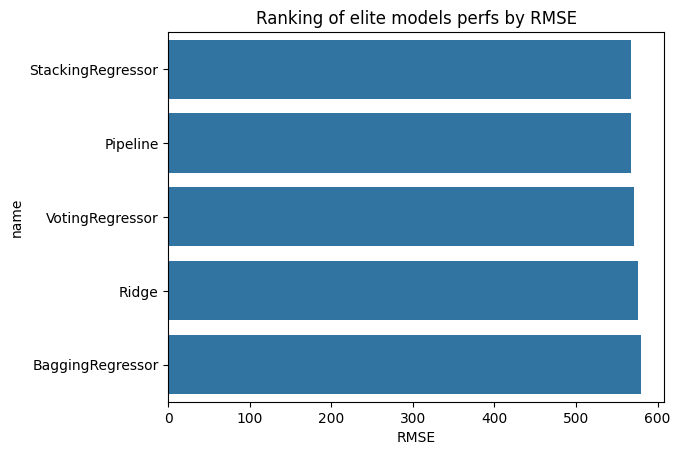

In [168]:
elite_df = pd.DataFrame({
    'name': model_names,
    'RMSE': model_rmse,
    'R2_score': model_r2_score
}).sort_values('RMSE')

visualization_regression_perfs(elite_df, 'Ranking of elite models perfs by RMSE')
plt.savefig('figures/Ranking of elite models perfs by RMSE')

In [136]:
save_perfs(elite_df, 'Elite_models_perfs')

# BEST MODEL OBSERVATIONS

## Model saving

In [138]:
save_model(ensemble_stacking,'midas v0.2')

## DATA VISUALISATION

In [154]:
dates = pd.date_range(start='2026-02-07', end='2026-06-24', freq='D')

In [161]:
y_preds = ensemble_stacking.predict(X_test)
preds = pd.DataFrame(y_preds, columns=['BTC-USD'], index=dates)
observations = pd.concat([y_test, preds], axis=1)

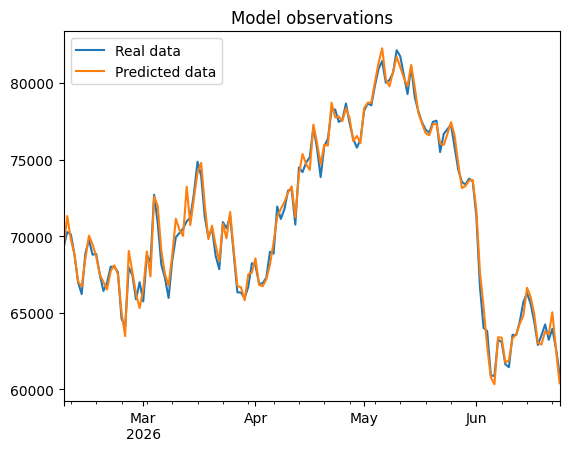

In [166]:
plt.title('Model observations')
observations.iloc[:,0].plot()
observations.iloc[:,1].plot()

plt.legend(['Real data', 'Predicted data'])

plt.savefig('figures/model_observations.png')